In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv( "SMSSpamCollection.txt", sep="\t", header=None, names=["label", "text"] )

In [3]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.loc[0, 'text']

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [5]:
df.loc[1, 'text']

'Ok lar... Joking wif u oni...'

In [6]:
df.shape

(5572, 2)

In [7]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
df['label'].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # remove numbers/punctuations
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

In [11]:
df["clean_text"] = df["text"].apply(clean_text)

In [12]:
df[["label", "text", "clean_text"]].head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [13]:
pd.set_option("display.max_colwidth", None)

In [14]:
df[["label", "text", "clean_text"]].head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though


In [15]:
df["clean_text"]

0                                 go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1                                                                                                                ok lar joking wif u oni
2         free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s
3                                                                                            u dun say so early hor u c already then say
4                                                                           nah i don t think he goes to usf he lives around here though
                                                                      ...                                                               
5567    this is the nd time we have tried contact u u have won the pound prize claim is easy call now only p per minute bt national rate
5568                                     

In [16]:
X_text = df["clean_text"]
y = df["label"]

X_text.shape, y.shape

((5572,), (5572,))

In [17]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_text.shape, X_test_text.shape

((4457,), (1115,))

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

X_train.shape, X_test.shape

((4457, 6564), (1115, 6564))

In [19]:
#MODEL 1: NAIVE BAYES (TRAIN + EVALUATE)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.967713004484305

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



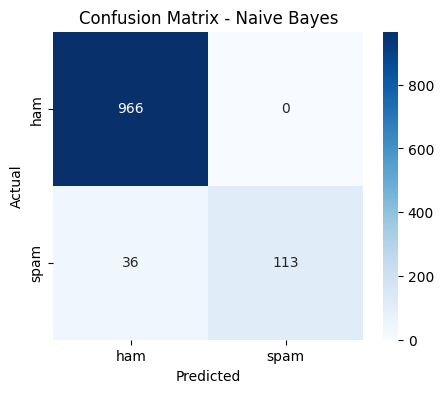

In [20]:
#NAIVE BAYES CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
#MODEL 2: LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9659192825112107

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



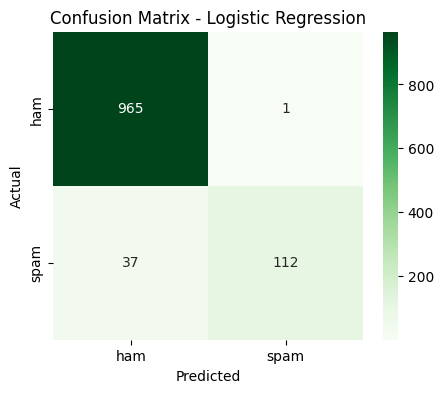

In [22]:
#LOGISTIC REGRESSION CONFUSION MATRIX

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
#Sample messages 

sample_messages = [
    "Congratulations! You won a free prize. Call now!",
    "Hey, are we meeting tomorrow?",
    "Urgent! Your bank account is compromised. Click the link.",
    "Can you send me the class notes?",
    "WIN cash now by replying YES!",
    "Limited time offer! Get 50% Discount today only",
    "Are you free for lunch later?",
    "You have been selected for a cash reward. Claim now",
    "Don't forget to submit the assignment tonight",
    "Call this number immediately to avoid account suspension",
    "Happy birthday! Hope you have a great day",
    "Free entry into weekly competition. Text WIN to 12345",
    "Let's catch up this weekend",
    "Your OTP is 482910. Do not share it with anyone",
    "Exclusive deal just for you. Click to know more"
]

In [24]:
def preprocess_sample(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample_clean = [preprocess_sample(msg) for msg in sample_messages]
sample_vec = vectorizer.transform(sample_clean)

In [25]:
print("Naive Bayes Predictions:")
for msg, pred in zip(sample_messages, nb.predict(sample_vec)):
    print(f"Text: {msg}\nPrediction: {pred}\n")

Naive Bayes Predictions:
Text: Congratulations! You won a free prize. Call now!
Prediction: spam

Text: Hey, are we meeting tomorrow?
Prediction: ham

Text: Urgent! Your bank account is compromised. Click the link.
Prediction: ham

Text: Can you send me the class notes?
Prediction: ham

Text: WIN cash now by replying YES!
Prediction: spam

Text: Limited time offer! Get 50% Discount today only
Prediction: ham

Text: Are you free for lunch later?
Prediction: ham

Text: You have been selected for a cash reward. Claim now
Prediction: spam

Text: Don't forget to submit the assignment tonight
Prediction: ham

Text: Call this number immediately to avoid account suspension
Prediction: ham

Text: Happy birthday! Hope you have a great day
Prediction: ham

Text: Free entry into weekly competition. Text WIN to 12345
Prediction: spam

Text: Let's catch up this weekend
Prediction: ham

Text: Your OTP is 482910. Do not share it with anyone
Prediction: ham

Text: Exclusive deal just for you. Click to 

In [26]:
print("Logistic Regression Predictions:")
for msg, pred in zip(sample_messages, lr.predict(sample_vec)):
    print(f"Text: {msg}\nPrediction: {pred}\n")

Logistic Regression Predictions:
Text: Congratulations! You won a free prize. Call now!
Prediction: spam

Text: Hey, are we meeting tomorrow?
Prediction: ham

Text: Urgent! Your bank account is compromised. Click the link.
Prediction: ham

Text: Can you send me the class notes?
Prediction: ham

Text: WIN cash now by replying YES!
Prediction: ham

Text: Limited time offer! Get 50% Discount today only
Prediction: ham

Text: Are you free for lunch later?
Prediction: ham

Text: You have been selected for a cash reward. Claim now
Prediction: spam

Text: Don't forget to submit the assignment tonight
Prediction: ham

Text: Call this number immediately to avoid account suspension
Prediction: ham

Text: Happy birthday! Hope you have a great day
Prediction: ham

Text: Free entry into weekly competition. Text WIN to 12345
Prediction: spam

Text: Let's catch up this weekend
Prediction: ham

Text: Your OTP is 482910. Do not share it with anyone
Prediction: ham

Text: Exclusive deal just for you. Cl